# Gry Szczepionkowe na Sieciach Społecznych: Symulacje i Analiza Numeryczna

Niniejszy notatnik Jupyter stanowi główną część obliczeniową interdyscyplinarnego projektu łączącego teorię gier, epidemiologię, rachunek prawdopodobieństwa oraz analizę numeryczną. Projekt skupia się na modelowaniu decyzji o zaszczepieniu się z perspektywy racjonalnych jednostek powiązanych złożoną strukturą sieci społecznej.

## Cele badawcze i układ modelu

Analiza opiera się na założeniu, że każda jednostka (reprezentowana jako węzeł w grafie) podejmuje decyzję o przyjęciu szczepionki, optymalizując własną wypłatę – ważąc pewny koszt szczepienia z ryzykiem i kosztem ewentualnego zakażenia. W notatniku zaimplementowano i omówiono następujące elementy:

* **Generowanie struktur sieciowych:** Tworzenie i analiza topologii grafów (np. modele Barabási-Albert, Erdős-Rényi) reprezentujących rzeczywiste interakcje społeczne.
* **Stochastyczna dynamika epidemii:** Symulacja rozprzestrzeniania się patogenu na sieci (warianty modeli SIR/SIS) przy wykorzystaniu symulacji Monte Carlo.
* **Teoriogrowa analiza decyzyjna:** Implementacja algorytmów ewaluujących strategie jednostek, poszukiwanie punktów równowagi Nasha oraz porównanie ich z optimum społecznym.
* **Ewaluacja numeryczna:** Numeryczna estymacja prawdopodobieństwa wybuchu dużej epidemii (zdarzenia rzadkie) oraz wizualizacja wyników w przestrzeni parametrów decyzyjnych.

## Środowisko i zależności

Do poprawnego uruchomienia symulacji i wygenerowania wykresów wymagane są następujące pakiety:
* `numpy`, `scipy` (główne obliczenia numeryczne i statystyczne)
* `networkx` (przetwarzanie i analiza grafów)
* `matplotlib` (wizualizacja danych i topologii sieci)
* `random` (modelowanie procesów losowych)

In [1]:
import numpy as np
import scipy
import networkx as nx
import random
import matplotlib.pyplot as plt

## Implementacja modeli sieciowych i symulacje

Poniżej zaimplementowano kluczowe mechanizmy generujące środowisko do symulacji epidemii. Obliczenia opierają się na wbudowanym module **`random`** (obsługa procesów stochastycznych i rozkładów probabilistycznych) oraz dwóch głównych pakietach zewnętrznych:
* **`networkx`** – generowanie i analiza struktur sieciowych (w szczególności modeli Erdősa-Rényiego oraz Barabásiego-Alberta).
* **`matplotlib`** – rysowanie badanych grafów i graficzna prezentacja wyników symulacji.

### Sieć społeczna na grafie

Poniższy skrypt generuje przykładowe reprezentacje sieci o różnej złożoności, porównując topologię losową Erdősa-Rényiego (ER) z bezskalową siecią Barabásiego-Alberta (BA). Węzły są skalowane proporcjonalnie do ich stopnia (liczby połączeń).

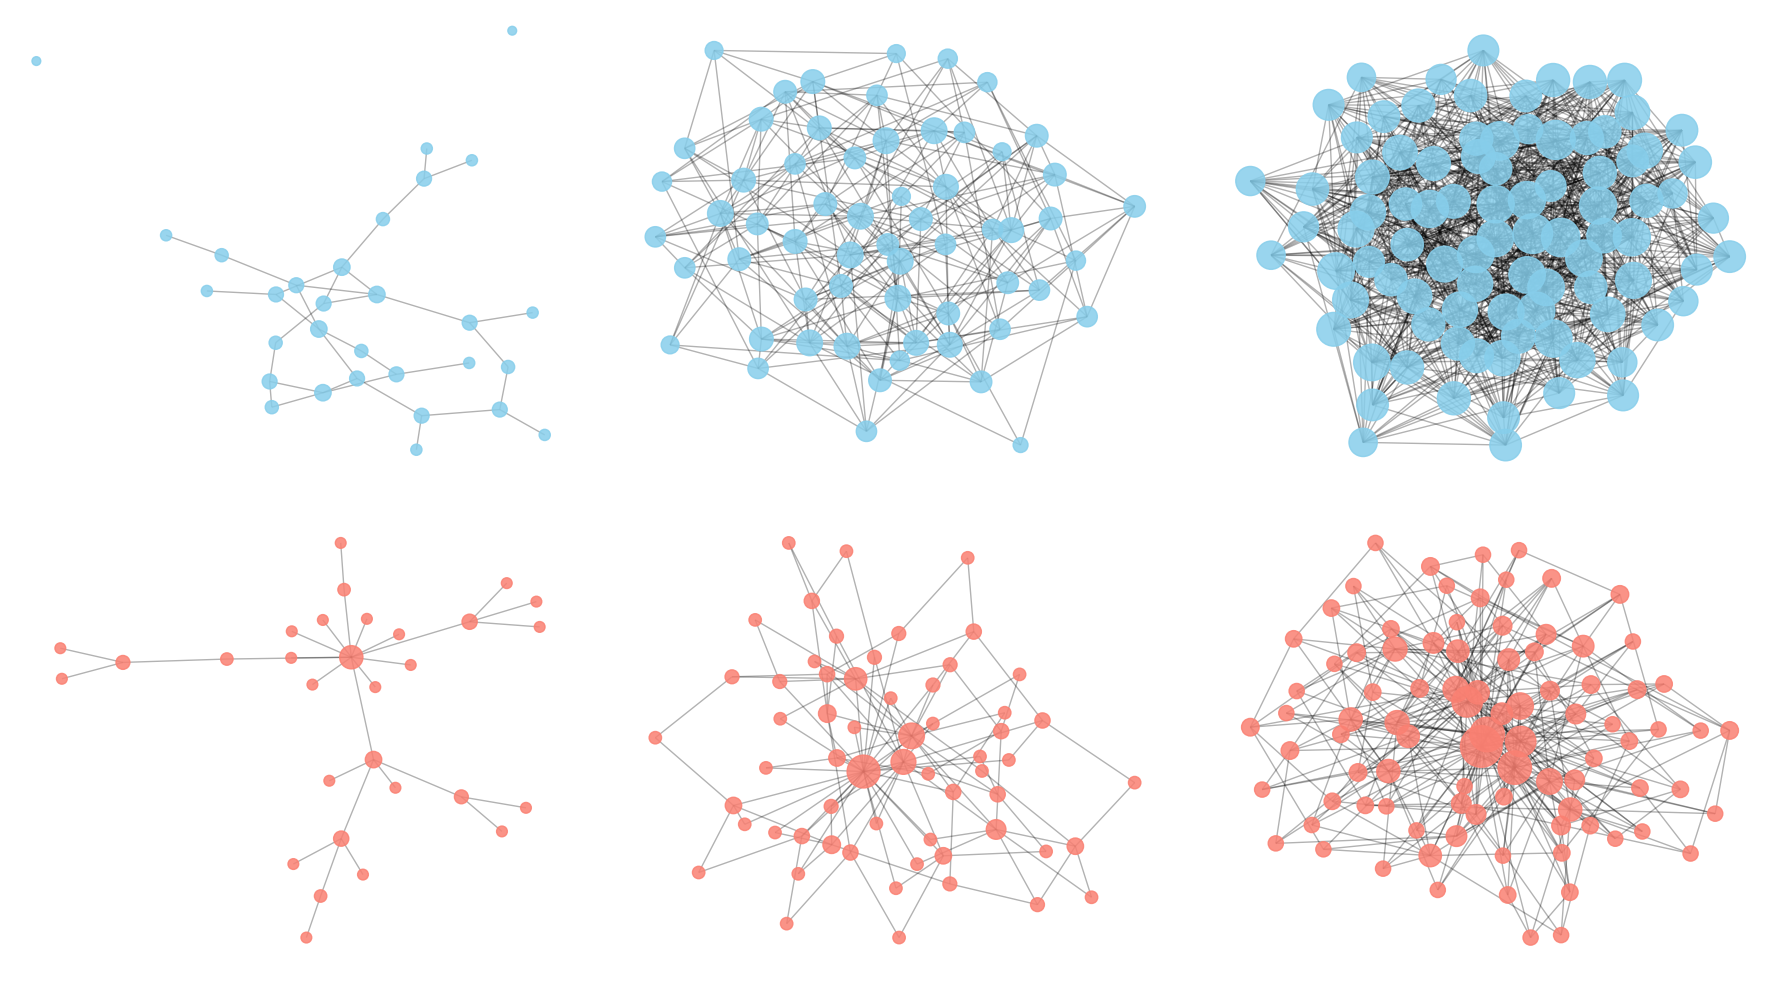

In [2]:
# Uklad 2 wiersze x 3 kolumny (Gora: ER, Dol: BA)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# -------------------------------------------------------------------
# 1. GRAFY ERDOSA-RENYIEGO (ER) - Rozne parametry (N, p)
# -------------------------------------------------------------------
er_params = [
    {"N": 30, "p": 0.08},  # Mala, rzadka siec
    {"N": 60, "p": 0.15},  # Srednia siec
    {"N": 90, "p": 0.25}   # Duza, gesta siec
]

for i, params in enumerate(er_params):
    N, p = params["N"], params["p"]
    G_er = nx.erdos_renyi_graph(n=N, p=p, seed=42)
    avg_k = p * (N - 1)
    
    pos = nx.spring_layout(G_er, seed=42)
    sizes = [d * 25 + 40 for _, d in G_er.degree()]
    
    ax = axes[0, i]
    nx.draw_networkx_nodes(G_er, pos, ax=ax, node_size=sizes, node_color='skyblue', alpha=0.85)
    nx.draw_networkx_edges(G_er, pos, ax=ax, alpha=0.3)
    
    ax.axis('off')

# -------------------------------------------------------------------
# 2. GRAFY BARABASIEGO-ALBERTA (BA) - Rozne parametry (N, m)
# -------------------------------------------------------------------
ba_params = [
    {"N": 30, "m": 1},  # Minimalne polaczenia (struktura drzewiasta)
    {"N": 60, "m": 2},  # Standardowa siec z hubami
    {"N": 90, "m": 4}   # Duza siec z silnymi, gestymi hubami
]

for i, params in enumerate(ba_params):
    N, m = params["N"], params["m"]
    G_ba = nx.barabasi_albert_graph(n=N, m=m, seed=42)
    avg_k = 2 * m
    
    pos = nx.spring_layout(G_ba, seed=42)
    sizes = [d * 20 + 40 for _, d in G_ba.degree()]
    
    ax = axes[1, i]
    nx.draw_networkx_nodes(G_ba, pos, ax=ax, node_size=sizes, node_color='salmon', alpha=0.85)
    nx.draw_networkx_edges(G_ba, pos, ax=ax, alpha=0.3)
    
    ax.axis('off')

plt.tight_layout()
plt.show()

### Inicjalizacja modelu SIR na grafie losowym

Poniższy skrypt odpowiada za wygenerowanie grafu Erdősa-Rényiego oraz inicjalizację początkowych stanów agentów. Każdy węzeł losuje swój profil strategii: decyduje się na szczepienie z prawdopodobieństwem określonym przez współczynnik $v_{rate}$ (otrzymując status `R`), lub pozostaje podatny na zakażenie (status `S`). Następnie, spośród grupy osób niezaszczepionych, wybierany jest losowo „pacjent zero”, który inicjuje epidemię (status `I`). 

Wizualizacja uruchamiana na końcu komórki przedstawia wylosowaną topologię sieci z odpowiednio pokolorowanymi węzłami.

Pacjent zero to węzeł nr: 4


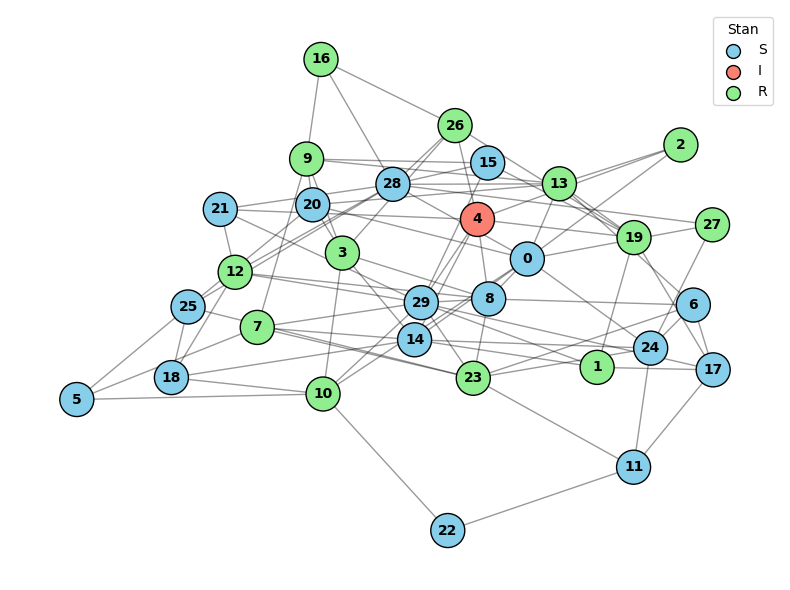

In [3]:
def initialize_epidemic_graph(N=15, p=0.2, v_rate=0.3, seed=42):
    random.seed(seed)

    # 1. Generowanie grafu
    G = nx.erdos_renyi_graph(n=N, p=p, seed=seed)

    # 2. Losowanie strategii (S lub R) dla kazdego wierzcholka
    # v_rate = prawdopodobienstwo, ze agent wybierze szczepienie (R)
    for node in G.nodes():
        G.nodes[node]["state"] = "R" if random.random() < v_rate else "S"

    # 3. Losowanie pacjenta zero ('I') spośród niezaszczepionych ('S')
    susceptible_nodes = [
        n for n, attr in G.nodes(data=True) if attr["state"] == "S"
    ]

    if susceptible_nodes:
        patient_zero = random.choice(susceptible_nodes)
    else:
        patient_zero = random.choice(list(G.nodes()))

    G.nodes[patient_zero]["state"] = "I"

    return G, patient_zero

def draw_graph(G):
    color_map = {"S": "skyblue", "I": "salmon", "R": "lightgreen"}
    node_colors = [color_map[G.nodes[n]["state"]] for n in G.nodes()]

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, node_size=600, edgecolors="black"
    )
    nx.draw_networkx_edges(G, pos, alpha=0.4)
    nx.draw_networkx_labels(
        G, pos, font_size=10, font_weight="bold", font_color="black"
    )

    # Legenda
    for state, color in color_map.items():
        plt.scatter([], [], c=color, label=state, edgecolors="black", s=100)

    plt.legend(title="Stan")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Uruchomienie
G, p0 = initialize_epidemic_graph(N=30, p=0.2, v_rate=0.3)
print(f"Pacjent zero to węzeł nr: {p0}")
draw_graph(G)

### Symulacja przebiegu epidemii (Model SIR)

Mając przygotowaną topologię sieci oraz wylosowane profile strategii graczy (zaszczepieni i niezaszczepieni), możemy przejść do właściwego modelowania dynamiki rozprzestrzeniania się patogenu. 

Poniższa funkcja przeprowadza iteracyjną symulację epidemii w oparciu o klasyczny model SIR. Algorytm w każdym kroku czasowym sprawdza prawdopodobieństwo transmisji wirusa zakażonego węzła na jego podatnych sąsiadów (z parametrem `beta`) oraz prawdopodobieństwo wyzdrowienia (z parametrem `gamma`). Symulacja trwa do momentu całkowitego wygaszenia choroby w sieci (brak węzłów w stanie `I`), raportując po drodze statystyki dotyczące populacji.

In [4]:
def run_sir_simulation(G, beta=1 / 3, gamma=1 / 2, verbose=True):
    """Przeprowadza symulację SIR na podanym grafie G az do wygaszenia ognisk zakazen (I = 0).

    - beta: prawdopodobieństwo transmisji przez krawędź w jednym kroku (1/3)
    - gamma: prawdopodobieństwo wyzdrowienia w jednym kroku (1/2)
    """
    t = 0

    if verbose:
        print("=== Start Symulacji SIR ===")

    while True:
        # Wyszukujemy węzły aktualnie chorujące
        infected = [n for n in G if G.nodes[n]["state"] == "I"]

        # Warunek stopu: brak chorujących (I = 0)
        if not infected:
            if verbose:
                print(f"\n[Koniec] Epidemia wygasła w kroku t = {t}.")
            break

        t += 1
        newly_infected = set()
        newly_recovered = set()

        # 1. Faza transmisji (S -> I)
        for u in infected:
            for v in G.neighbors(u):
                if G.nodes[v]["state"] == "S":
                    if random.random() < beta:
                        newly_infected.add(v)

        # 2. Faza wyzdrowienia (I -> R)
        for u in infected:
            if random.random() < gamma:
                newly_recovered.add(u)

        # 3. Synchroniczna aktualizacja stanów węzłów po kroku t
        for v in newly_infected:
            G.nodes[v]["state"] = "I"

        for u in newly_recovered:
            G.nodes[u]["state"] = "R"

        # Raportowanie stanu sieci
        if verbose:
            s_cnt = sum(1 for n in G if G.nodes[n]["state"] == "S")
            i_cnt = sum(1 for n in G if G.nodes[n]["state"] == "I")
            r_cnt = sum(1 for n in G if G.nodes[n]["state"] == "R")
            print(
                f"Krok t = {t:2d} | S: {s_cnt:2d} | I: {i_cnt:2d} | R: {r_cnt:2d} | "
                f"Nowe infekcje: {len(newly_infected)} | Wyzdrowieli: {len(newly_recovered)}"
            )

    return G, t

### Zależności między parametrami w grafach pełnych

Poniższa funkcja szacuje indywidualne ryzyko zachorowania niezaszczepionego agenta $\pi(n)$ w grafie pełnym $K_n$ w zależności od wielkości populacji $n \in [10, 10\,000]$ oraz różnych reżimów zakaźności patogenu $R_0$. 

Model opiera się na dyskretnym procesie epidemii SIR, w którym prawdopodobieństwo transmisji wirusa wzdłuż każdej krawędzi jest skalowane zgodnie z relacją $p_{\text{trans}} = \frac{R_0}{n-1}$. Do estymacji tego ryzyka wykorzystano wektorową symulację Monte Carlo, co pozwala na równoległe obliczenie tysięcy niezależnych prób i znaczne przyspieszenie działania algorytmu.

In [5]:
def simulate_pi_r0_vectorized(n, R_0, num_sims=5000):
    """
    Wektorowa symulacja Monte Carlo ryzyka pi(n) w grafie K_n.
    """
    if n <= 1:
        return 0.0
    
    # Skalowanie prawdopodobienstwa transmisji na krawedzi
    p_trans = min(R_0 / (n - 1), 1.0)
    
    # Macierz stanu zakazen dla num_sims niezaleznych prób jednoczesnie
    infected = np.zeros((num_sims, n), dtype=bool)
    infected[:, 0] = True  # Pacjent Zero ma indeks 0
    newly_infected = infected.copy()
    
    while np.any(newly_infected):
        # Liczba nowych ognisk zakazenia w kazdej symulacji
        num_new = newly_infected.sum(axis=1, keepdims=True)
        
        # Prawdopodobienstwo unikniecia infekcji ze wszystkich nowych zrodel
        prob_escape = (1.0 - p_trans) ** num_new
        
        susceptible = ~infected
        rand_vals = np.random.rand(num_sims, n)
        
        # Wyznaczenie wezlow zakazonych w kolejnej fali
        next_infected = susceptible & (rand_vals >= prob_escape)
        infected |= next_infected
        newly_infected = next_infected

    # Srednia calkowita wielkosc epidemii E[X] przeskalowana do indywidualnego ryzyka
    avg_total = np.mean(infected.sum(axis=1))
    return (avg_total - 1) / (n - 1)

### Implementacja racjonalnego myślenia agentów

Kluczowym elementem modelu jest analiza decyzyjna poszczególnych jednostek w sieci. Poniższa funkcja odpowiada za estymację wektora prawdopodobieństw zakażenia $\boldsymbol{\pi}$ dla poszczególnych agentów z wykorzystaniem metody Monte Carlo. 

Dla każdego węzła $i$ algorytm bada scenariusz alternatywny: wymusza stan braku zaszczepienia (tworząc profil strategii $(0, a_{-i})$), a następnie przeprowadza serię $M$ niezależnych symulacji przebiegu epidemii. Częstość empiryczna, z jaką dany agent ulega zakażeniu we wszystkich próbach, stanowi precyzyjne przybliżenie jego indywidualnego ryzyka zachorowania. Wartość ta jest w kolejnych krokach kluczowa do ewaluacji opłacalności szczepienia i wyznaczania punktów równowagi Nasha.

In [6]:
def estimate_pi(G, strategy_profile, beta=1/3, gamma=1/2, M=None):
    """
    Estymuje wektor prawdopodobienstw zakazenia pi_i(0, a_{-i}) metoda Monte Carlo.

    Parameters:
    - G: nx.Graph, topologia sieci
    - strategy_profile: dict {node: 0 lub 1}, gdzie 1 = zaszczepiony, 0 = niezaszczepiony
    - beta, gamma: parametry epidemii
    - M: liczba symulacji na agenta (domyślnie N * 100)

    Returns:
    - pi_hat: dict {node: prob_infection}, wyestymowany wektor pi
    """
    N = G.number_of_nodes()
    if M is None:
        M = N * 100

    pi_hat = {}

    for i in G.nodes():
        # 1. Tworzymy profil (0, a_{-i}) -- wymuszamy brak szczepienia agenta i
        test_profile = strategy_profile.copy()
        test_profile[i] = 0

        # Zbiór niezaszczepionych graczy (w tym agent i)
        S_nodes = [node for node, state in test_profile.items() if state == 0]

        infections_count = 0

        # 2. M niezaleznych symulacji Monte Carlo dla gracza i
        for _ in range(M):
            H = G.copy()

            # Ustawienie stanów początkowych S / R
            for node in H.nodes():
                H.nodes[node]["state"] = "R" if test_profile[node] == 1 else "S"

            # Losowanie pacjenta zero sposrod niezaszczepionych (S)
            patient_zero = random.choice(S_nodes)
            H.nodes[patient_zero]["state"] = "I"

            # Przeprowadzenie symulacji SIR (bez wypisywania komunikatów)
            run_sir_simulation(H, beta=beta, gamma=gamma, verbose=False)

            # 3. Jesli agent i zmienil stan z 'S' na 'I' lub 'R', ulegl zakazeniu
            if H.nodes[i]["state"] != "S":
                infections_count += 1

        # Częstość empiryczna M_i / M
        pi_hat[i] = infections_count / M

    return pi_hat

### Weryfikacja równowagi Nasha

Kluczowym elementem funkcji `is_nash_equilibrium` jest wprowadzenie marginesu tolerancji numerycznej `tol`. W sytuacjach, gdy teoretyczne ryzyko zakażenia danego agenta leży dokładnie na granicy decyzyjnej ($\pi_i = r$), empiryczny estymator Monte Carlo $\hat{\pi}_i$ podlega naturalnym fluktuacjom stochastycznym wynikającym ze skończonej próby $M$. 

Bez zdefiniowanego przedziału obojętności, nawet znikomy szum próbkowania mógłby sprawić, że wyestymowana wartość minimalnie przekroczyłaby próg $r$ (np. $\hat{\pi}_i = 0.501$ dla $r = 0.5$). Prowadziłoby to do błędnego zakwalifikowania agenta jako niestabilnego i sztucznego wykrycia odstępstwa (ang. *false positive*). Zastosowanie strefy $[r - \text{tol}, r + \text{tol}]$ zapewnia odporność algorytmu na błędy estymacji i umożliwia poprawną identyfikację słabych równowag Nasha.

In [7]:
def is_nash_equilibrium(G, strategy_profile, r=0.5, beta=1 / 3, gamma=1 / 2, M=None, tol=1e-2, verbose=True):
    pi_hat = estimate_pi(G, strategy_profile, beta=beta, gamma=gamma, M=M)

    is_ne = True
    deviations = {}

    for node in G.nodes():
        current_action = strategy_profile[node]
        pi_i = pi_hat[node]

        # Uwzglednienie tolerancji dla wartosci na granicy r
        if pi_i > r + tol:
            best_response = 1
        elif pi_i < r - tol:
            best_response = 0
        else:
            best_response = current_action  # Brak jednoznacznego bodzca do zmiany (obojetnosc)

        if current_action != best_response:
            is_ne = False
            deviations[node] = best_response

    return is_ne, deviations

### Weryfikacja równowagi Nasha dla testowych topologii grafowych

Aby przetestować poprawność działania zaimplementowanych algorytmów, przygotowano zestaw różnorodnych przypadków testowych obejmujących kluczowe struktury grafowe. Skrypt weryfikuje stabilność wytypowanych profili strategii (odzwierciedlających decyzje o szczepieniu) w następujących scenariuszach:

1. **Losowy graf spójny:** Przypadek testujący zachowanie populacji przy pełnym wyszczepieniu całej sieci.
2. **Graf gwiazdy ($K_{1,3}$):** Układ z wyraźnym centrum (hubem) o wysokim stopniu oraz liśćmi na obrzeżach.
3. **Graf diamentu ($K_4 \setminus \{e\}$):** Struktura o średniej gęstości połączeń z węzłami o zróżnicowanym stopniu.
4. **Cykl z liśćmi ($C_4$):** Złożona topologia hybrydowa łącząca właściwości zamkniętego obwodu i luźnych odgałęzień.

Dla każdego przypadku skrypt uruchamia procedurę Monte Carlo, sprawdza warunek równowagi Nasha przy ustalonym progu kosztu szczepienia $r = 0.5$ i raportuje ewentualne odstępstwa graczy, którzy mogliby opłacalnie zmienić swoją decyzję.

In [8]:
# 1. Przykład 1: Losowy spójny graf z pełnym szczepieniem a = (1, ..., 1)
while True:
    G1 = nx.erdos_renyi_graph(n=8, p=0.4, seed=42)
    if nx.is_connected(G1):
        break
profile1 = {n: 1 for n in G1.nodes()}

# 2. Przykład 2: Gwiazda K_{1,3} (Hub zaszczepiony, liście niezaszczepione)
G2 = nx.star_graph(3)  # Węzeł 0 to hub, węzły 1, 2, 3 to liście
profile2 = {0: 1, 1: 0, 2: 0, 3: 0}

# 3. Przykład 3: Diament K_4 \ {e} (Węzły o stopniu 3 zaszczepione, o stopniu 2 nie)
G3 = nx.Graph([(0, 1), (0, 2), (0, 3), (1, 2), (1, 3)])
profile3 = {0: 1, 1: 1, 2: 0, 3: 0}

# 4. Przykład 4: Cykl C_4 z 3 liśćmi (Profile a = (1,1,1,1,0,0,0))
G4 = nx.Graph([(1, 2), (2, 3), (3, 4), (4, 1), (1, 5), (2, 6), (3, 7)])
profile4 = {1: 1, 2: 1, 3: 1, 4: 1, 5: 0, 6: 0, 7: 0}

# Zestawienie przypadków testowych
examples = [
    ("1. Losowy graf spójny (pełne szczepienie)", G1, profile1),
    ("2. Gwiazda K_{1,3} (hub R, liście S)", G2, profile2),
    ("3. Diament K_4 \\ {e} (stopień 3 R, stopień 2 S)", G3, profile3),
    ("4. Cykl C_4 z 3 liśćmi (cykl R, liście S)", G4, profile4),
]

# Weryfikacja hipotez analitycznych
for name, G, profile in examples:
    print(f"\n==========================================")
    print(f"TEST: {name}")
    print(f"==========================================")

    is_ne, dev = is_nash_equilibrium(
        G,
        profile,
        r=0.5,
        beta=1 / 2,
        gamma=1 / 2,
        M=2000,  # Liczba prób dla wysokiej dokładności
        verbose=False,
    )

    verdict = "RÓWNOWAGA NASHA" if is_ne else "BRAK RÓWNOWAGI"
    print(f"Wynik numeryczny: {verdict}")

    if not is_ne:
        print(f"Wykryte odstępstwa (gracz: BR_i): {dev}")


TEST: 1. Losowy graf spójny (pełne szczepienie)
Wynik numeryczny: RÓWNOWAGA NASHA

TEST: 2. Gwiazda K_{1,3} (hub R, liście S)
Wynik numeryczny: RÓWNOWAGA NASHA

TEST: 3. Diament K_4 \ {e} (stopień 3 R, stopień 2 S)
Wynik numeryczny: RÓWNOWAGA NASHA

TEST: 4. Cykl C_4 z 3 liśćmi (cykl R, liście S)
Wynik numeryczny: BRAK RÓWNOWAGI
Wykryte odstępstwa (gracz: BR_i): {1: 0, 2: 0, 3: 0, 4: 0}
